In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import make_pipeline

Importando os data-sets e visualizando os dados

In [2]:
train_df = pd.read_csv('train.csv', index_col=[0])
test_df = pd.read_csv('test.csv', index_col=[0])

In [3]:
train_df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
1,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
2,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia
3,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,Hernia
4,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,Hernia


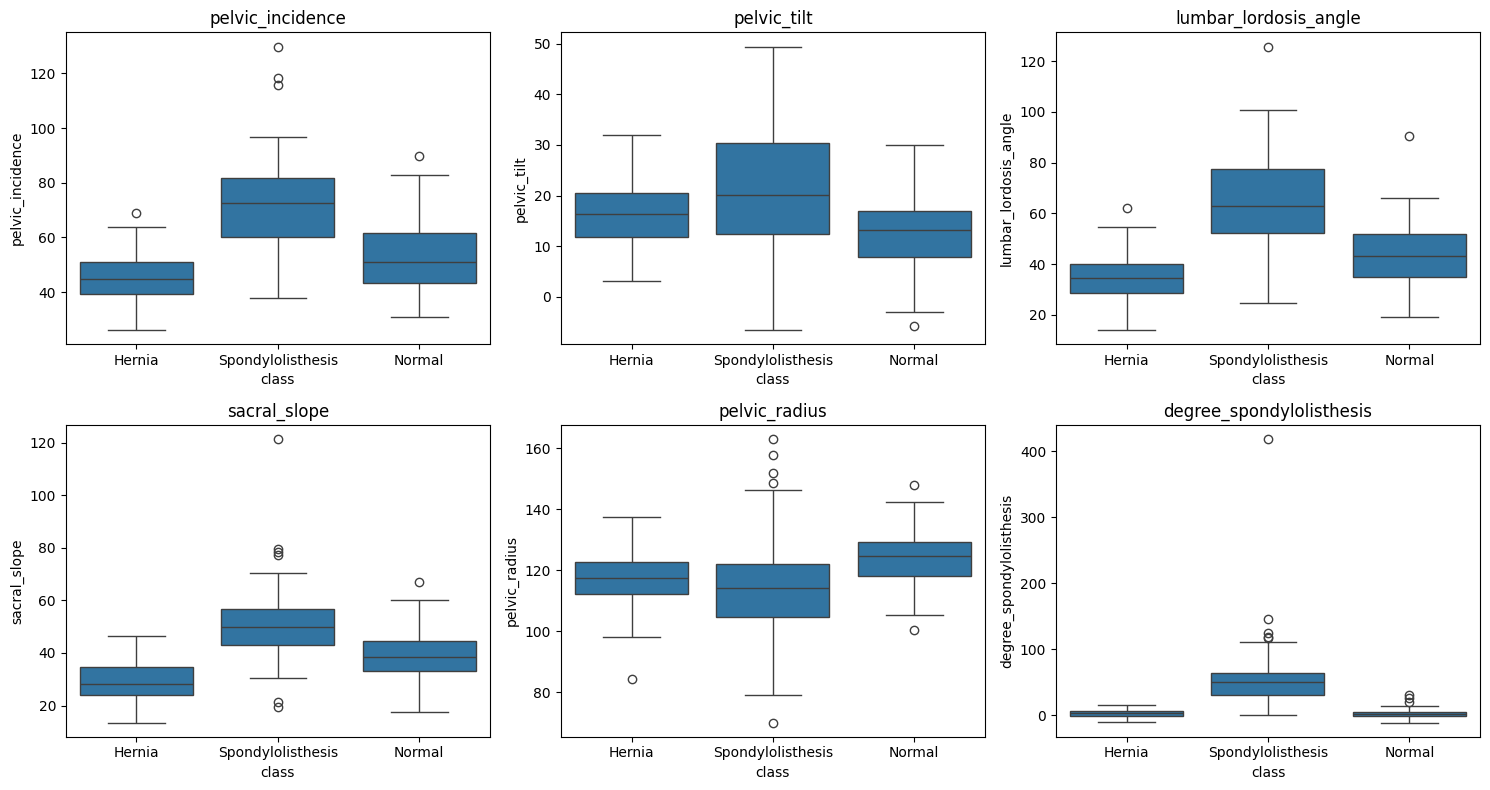

In [4]:
feature_cols = [c for c in train_df.columns if c != 'class']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.boxplot(data=train_df, x='class', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

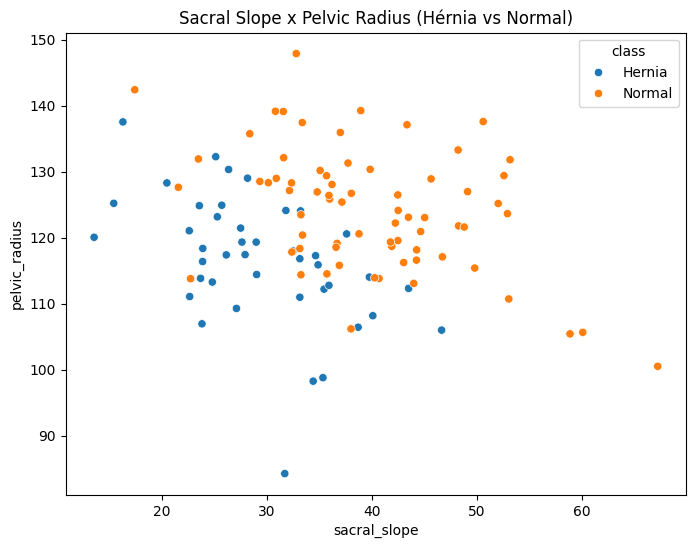

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=train_df[train_df['class'] != 'Spondylolisthesis'],
    x='sacral_slope', y='pelvic_radius', hue='class'
)
plt.title('Sacral Slope x Pelvic Radius (Hérnia vs Normal)')
plt.show()

Dividindo o dataset de treino: 80% treino e 20% teste

In [6]:
train_df['degree_spondylolisthesis'] = train_df['degree_spondylolisthesis'].clip(lower=-20, upper=120)
test_df['degree_spondylolisthesis'] = test_df['degree_spondylolisthesis'].clip(lower=-20, upper=120)

train_df['ds_log'] = np.sign(train_df['degree_spondylolisthesis']) * np.log1p(np.abs(train_df['degree_spondylolisthesis']))
test_df['ds_log'] = np.sign(test_df['degree_spondylolisthesis']) * np.log1p(np.abs(test_df['degree_spondylolisthesis']))

train_df = train_df.drop(columns=['pelvic_incidence'])
test_df = test_df.drop(columns=['pelvic_incidence'])


In [7]:
X = train_df.drop(columns=['class'])
y = train_df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)


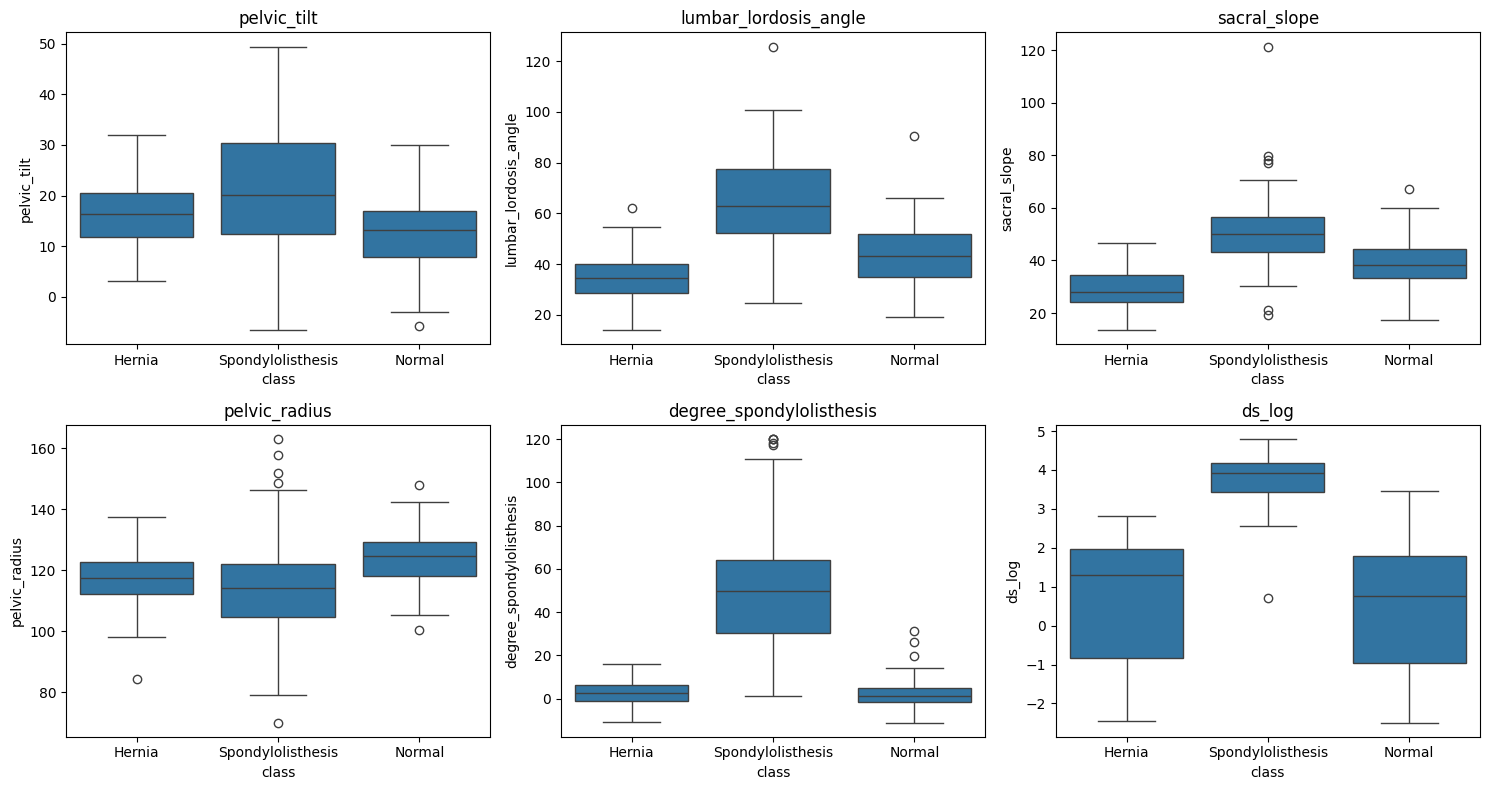

In [8]:
feature_cols = [c for c in train_df.columns if c != 'class']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.boxplot(data=train_df, x='class', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Definindo parâmetros para a validação cruzada

In [9]:
param_grid_stage1 = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'ccp_alpha': [0.0, 0.01],
    'class_weight': [None, 'balanced']  # Hernia tende a ser a classe minoritaria
}

param_grid_stage2 = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'ccp_alpha': [0.0, 0.01],
    'class_weight': [None, 'balanced']
}


In [10]:
model = DecisionTreeClassifier(random_state=42)

In [11]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00550509 0.00578035 0.00867052 0.00924855 0.00945875
 0.01109827 0.01114781 0.01256671 0.01801667 0.02987995 0.03243085
 0.06439853 0.34642826]


Grid Search

In [12]:
y_stage1_train = (y_train == 'Spondylolisthesis').astype(int)
y_stage1_test = (y_test == 'Spondylolisthesis').astype(int)  # útil pra avaliar a Etapa 1 sozinha

grid_stage1 = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_stage1,
    cv=cv,
    scoring='accuracy' 
)
grid_stage1.fit(X_train, y_stage1_train)
model_stage1 = grid_stage1.best_estimator_


In [13]:
# Etapa 2: so nos dados que NAO sao Spondylolisthesis
mask_nao_spondy = y_train != 'Spondylolisthesis'
X_train_stage2 = X_train[mask_nao_spondy]
y_train_stage2 = y_train[mask_nao_spondy]  # so Hernia ou Normal

grid_stage2 = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_stage2,
    cv=cv,
    scoring='accuracy'
)
grid_stage2.fit(X_train_stage2, y_train_stage2)
model_stage2 = grid_stage2.best_estimator_


In [14]:
# Predição em cascata
def predict_hierarquico(X):
    pred_stage1 = model_stage1.predict(X)
    final_preds = np.where(pred_stage1 == 1, 'Spondylolisthesis', None)
    
    idx_resto = np.where(pred_stage1 == 0)[0]
    if len(idx_resto) > 0:
        pred_stage2 = model_stage2.predict(X.iloc[idx_resto])
        final_preds[idx_resto] = pred_stage2
    
    return final_preds

In [15]:
from sklearn.metrics import classification_report


pred_stage1_test = model_stage1.predict(X_test)

print("STAGE 1")
print(classification_report(
    y_stage1_test,
    pred_stage1_test,
    target_names=[
        'Não Spondylolisthesis',
        'Spondylolisthesis'
    ]
))

STAGE 1
                       precision    recall  f1-score   support

Não Spondylolisthesis       0.96      1.00      0.98        23
    Spondylolisthesis       1.00      0.95      0.98        21

             accuracy                           0.98        44
            macro avg       0.98      0.98      0.98        44
         weighted avg       0.98      0.98      0.98        44



In [16]:
mask_test_nao_spondy = y_test != 'Spondylolisthesis'

X_test_stage2 = X_test[mask_test_nao_spondy]
y_test_stage2 = y_test[mask_test_nao_spondy]

pred_stage2_test = model_stage2.predict(X_test_stage2)

print("STAGE 2")
print(classification_report(y_test_stage2, pred_stage2_test))

STAGE 2
              precision    recall  f1-score   support

      Hernia       0.70      0.78      0.74         9
      Normal       0.85      0.79      0.81        14

    accuracy                           0.78        23
   macro avg       0.77      0.78      0.78        23
weighted avg       0.79      0.78      0.78        23



In [17]:
print("Melhores parâmetros Stage 1:")
print(grid_stage1.best_params_)

print("\nScore CV Stage 1:")
print(grid_stage1.best_score_)

print("\nMelhores parâmetros Stage 2:")
print(grid_stage2.best_params_)

print("\nScore CV Stage 2:")
print(grid_stage2.best_score_)

Melhores parâmetros Stage 1:
{'ccp_alpha': 0.01, 'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2}

Score CV Stage 1:
0.969187675070028

Melhores parâmetros Stage 2:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2}

Score CV Stage 2:
0.7494553376906317


Validacao cruzada da cascata completa


In [18]:
# Acuracia da cascata inteira nas 15 dobras, com o grid refeito dentro de cada dobra
scores = []

for idx_treino, idx_val in cv.split(X, y):
    X_tr, X_val = X.iloc[idx_treino], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_treino], y.iloc[idx_val]

    y_tr_stage1 = (y_tr == 'Spondylolisthesis').astype(int)
    m1 = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_stage1, cv=5, scoring='accuracy')
    m1.fit(X_tr, y_tr_stage1)

    resto = y_tr_stage1 == 0
    m2 = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_stage2, cv=5, scoring='accuracy')
    m2.fit(X_tr[resto], y_tr[resto])

    pred1 = m1.predict(X_val)
    preds = np.where(pred1 == 1, 'Spondylolisthesis', None)
    idx_resto = np.where(pred1 == 0)[0]
    if len(idx_resto) > 0:
        preds[idx_resto] = m2.predict(X_val.iloc[idx_resto])

    scores.append(accuracy_score(y_val, preds))

print('Acuracia media:', round(np.mean(scores), 4))
print('Desvio padrao :', round(np.std(scores), 4))
print('Pior fold     :', round(np.min(scores), 4))
print('Melhor fold   :', round(np.max(scores), 4))


Acuracia media: 0.8342
Desvio padrao : 0.0569
Pior fold     : 0.7209
Melhor fold   : 0.9302


In [19]:
# Pega as previsões e identifica os erros de Hérnia/Normal no X_test
predictions = predict_hierarquico(X_test)
mask_stage2 = (y_test.values != 'Spondylolisthesis') & (predictions != 'Spondylolisthesis')
erros_mask = mask_stage2 & (y_test.values != predictions)

X_test_stage2 = X_test[mask_stage2]
casos_errados = X_test[erros_mask]

# Qual folha cada caso errado caiu (usando a árvore final, ex: model_stage2)
folhas = model_stage2.apply(casos_errados)

print("Casos errados e a folha onde caíram:")
for idx, folha in zip(casos_errados.index, folhas):
    print(f"Índice {idx} -> nó folha {folha}")
    print(casos_errados.loc[idx])
    print('---')

Casos errados e a folha onde caíram:
Índice 166 -> nó folha 5
pelvic_tilt                   9.386298
lumbar_lordosis_angle        42.000000
sacral_slope                 28.345694
pelvic_radius               135.740926
degree_spondylolisthesis     13.683047
ds_log                        2.686694
Name: 166, dtype: float64
---
Índice 155 -> nó folha 8
pelvic_tilt                  26.328369
lumbar_lordosis_angle        50.958964
sacral_slope                 37.983498
pelvic_radius               106.177751
degree_spondylolisthesis      3.118221
ds_log                        1.415421
Name: 155, dtype: float64
---
Índice 18 -> nó folha 3
pelvic_tilt                  10.759454
lumbar_lordosis_angle        14.000000
sacral_slope                 15.388468
pelvic_radius               125.203296
degree_spondylolisthesis    -10.093108
ds_log                       -2.406324
Name: 18, dtype: float64
---
Índice 164 -> nó folha 5
pelvic_tilt                  13.815744
lumbar_lordosis_angle        40.34

In [20]:
predictions = predict_hierarquico(X_test)


Resultados

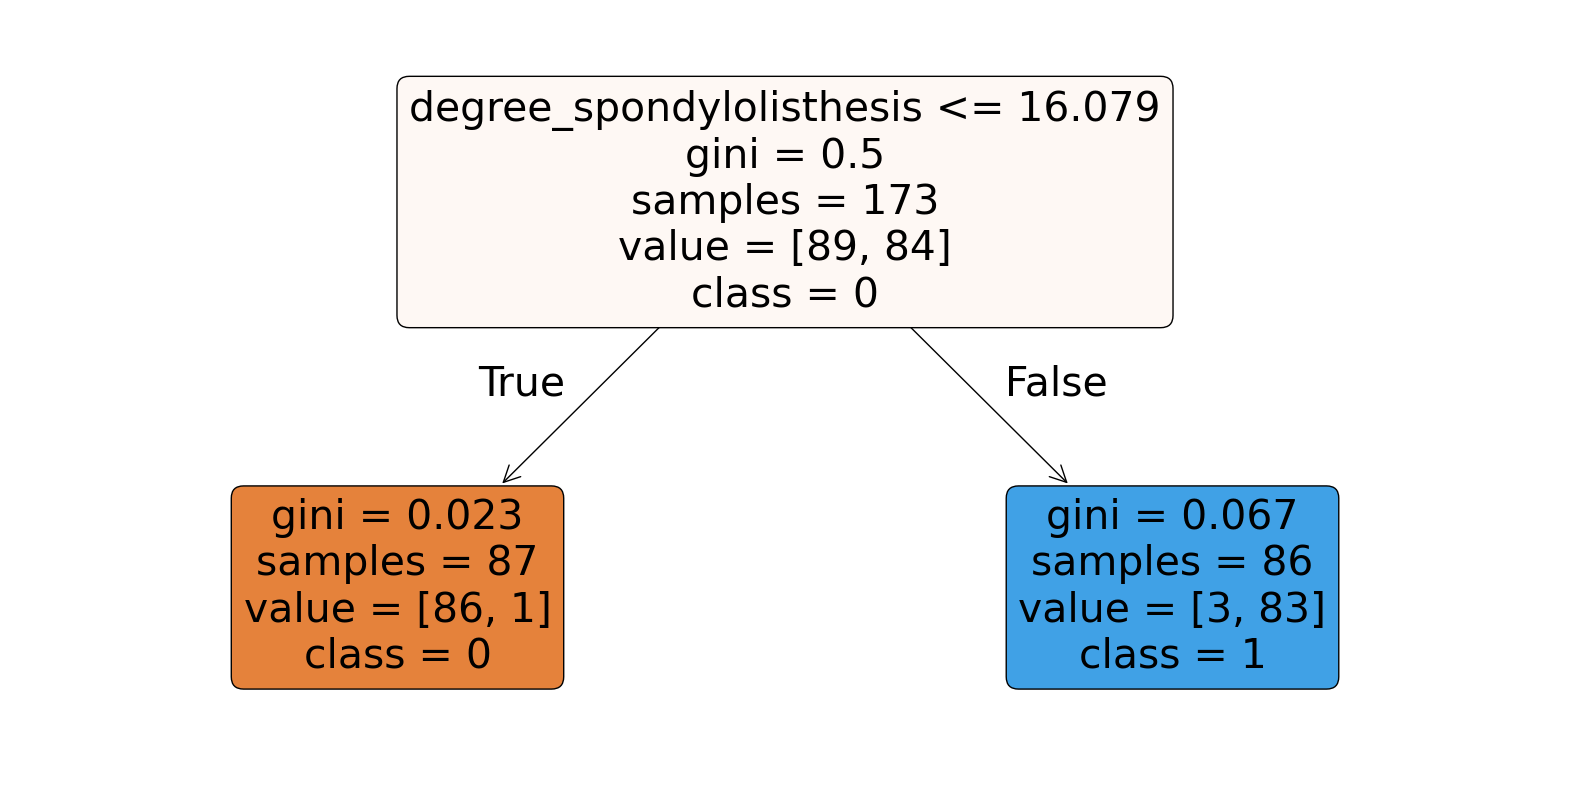

In [21]:
plt.figure(figsize=(20, 10))

plot_tree(
    model_stage1,
    feature_names=X_train_stage2.columns,
    class_names=[str(c) for c in model_stage1.classes_],
    filled=True,
    rounded=True
)

plt.show()

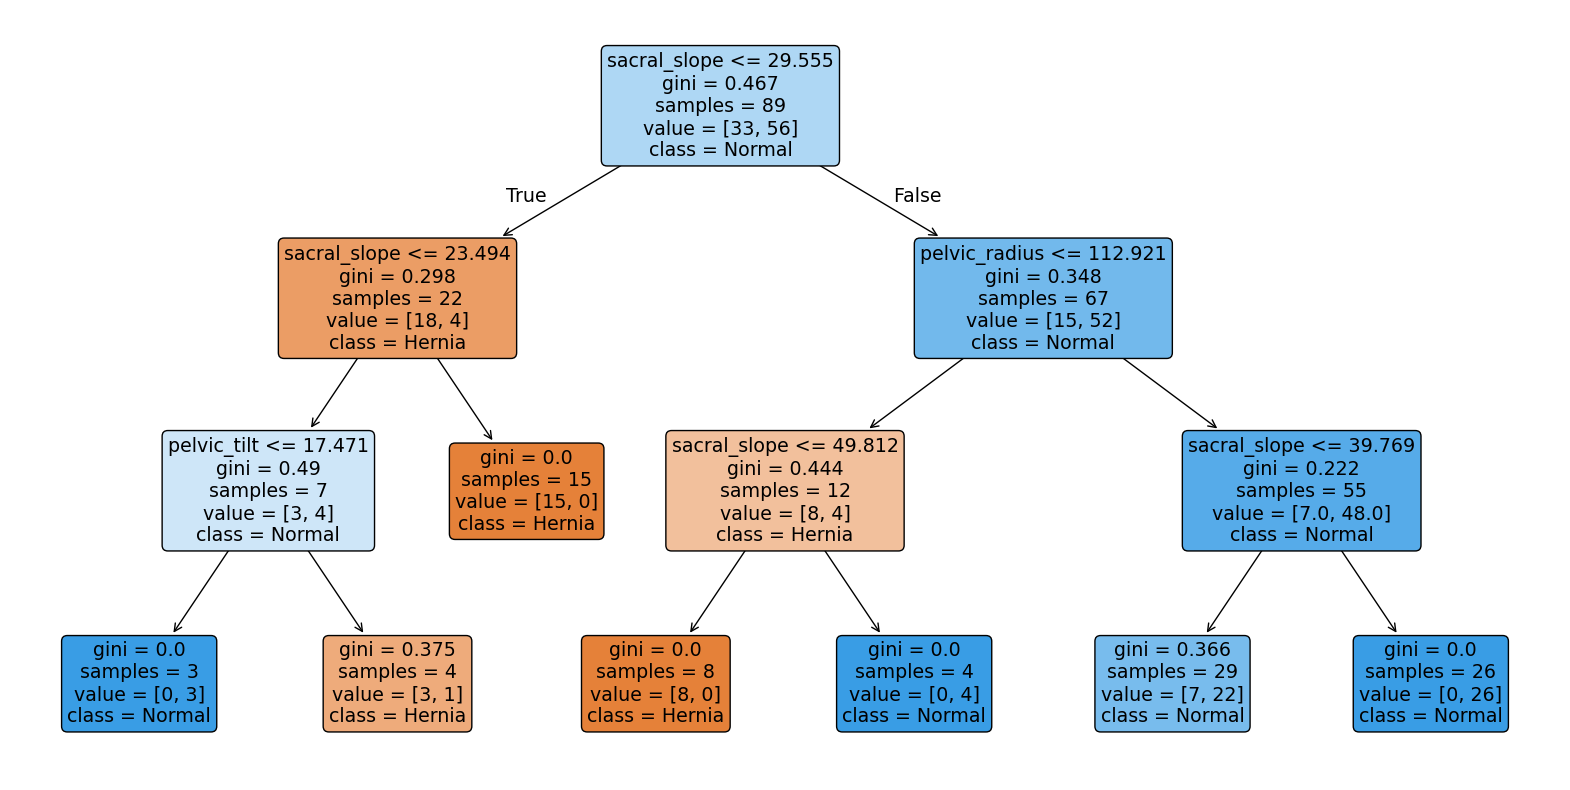

In [22]:
plt.figure(figsize=(20, 10))

plot_tree(
    model_stage2,
    feature_names=X_train_stage2.columns,
    class_names=model_stage2.classes_,
    filled=True,
    rounded=True
)

plt.show()

In [23]:
modelo_stage2 = model_stage2

importancias = pd.Series(
    modelo_stage2.feature_importances_,
    index=X_train_stage2.columns
).sort_values(ascending=False)

print(importancias)

sacral_slope                0.739500
pelvic_radius               0.194919
pelvic_tilt                 0.065581
lumbar_lordosis_angle       0.000000
degree_spondylolisthesis    0.000000
ds_log                      0.000000
dtype: float64


In [24]:
print('Accuracy:', accuracy_score(y_test, predictions))
print('F1:', f1_score(y_test, predictions, average='macro'))
print('Precision:', precision_score(y_test, predictions, average='macro'))
print('Recall:', recall_score(y_test, predictions, average='macro'))

Accuracy: 0.8636363636363636
F1: 0.8327220490250015
Precision: 0.8285714285714286
Recall: 0.8386243386243386


Matriz de confusão

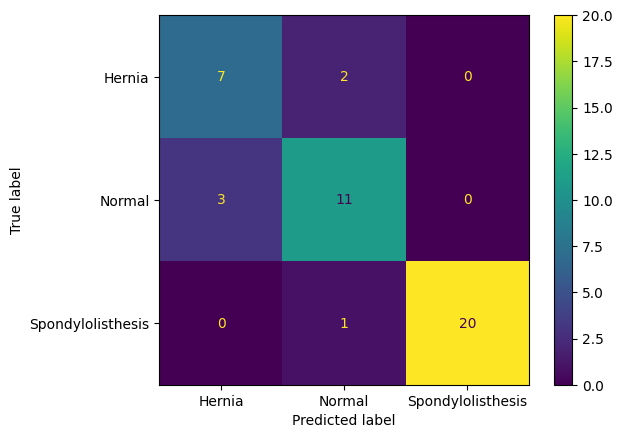

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test, predictions)

Treino final em todo o conjunto anotado


In [26]:
# Retreina os dois estagios usando as 217 amostras, nao so os 80% do split
y_stage1 = (y == 'Spondylolisthesis').astype(int)

grid_stage1_final = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_stage1,
    cv=cv,
    scoring='accuracy'
)
grid_stage1_final.fit(X, y_stage1)
model_stage1 = grid_stage1_final.best_estimator_

mask_resto = y != 'Spondylolisthesis'

grid_stage2_final = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_stage2,
    cv=cv,
    scoring='accuracy'
)
grid_stage2_final.fit(X[mask_resto], y[mask_resto])
model_stage2 = grid_stage2_final.best_estimator_

final_predictions = predict_hierarquico(test_df)


Criando arquivo de submissão

In [27]:
def create_submission_file(predictions, test_df, submission_file_name="submission.csv"):
    submission_df = pd.DataFrame({'id': test_df.index, 'Target': predictions})
    submission_df.to_csv(submission_file_name, index=False)
    print(f"Submission file '{submission_file_name}' created successfully.")

In [28]:
create_submission_file(final_predictions, test_df)

Submission file 'submission.csv' created successfully.
